In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, precision_score, auc, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
import optuna
from sklearn.feature_selection import RFECV
import joblib
from sklearn.ensemble import StackingClassifier

In [305]:
data = pd.read_csv('../data/processed/final_dataset_with_features.csv')

In [306]:
Y = data['label']
X = data.drop(columns=['label','text','chunk_count', 'source_category'])

In [307]:
corr_matrix = X.corr(method='spearman')

Pracę nad modelami rozpoczynamy od analizy korelacji między cechami. Wyznaczamy korelację Spearmana ze względu na szersze (nieliniowe), niż w przypadku korelacji Pearsona, pojęcie zależności między zmiennymi.

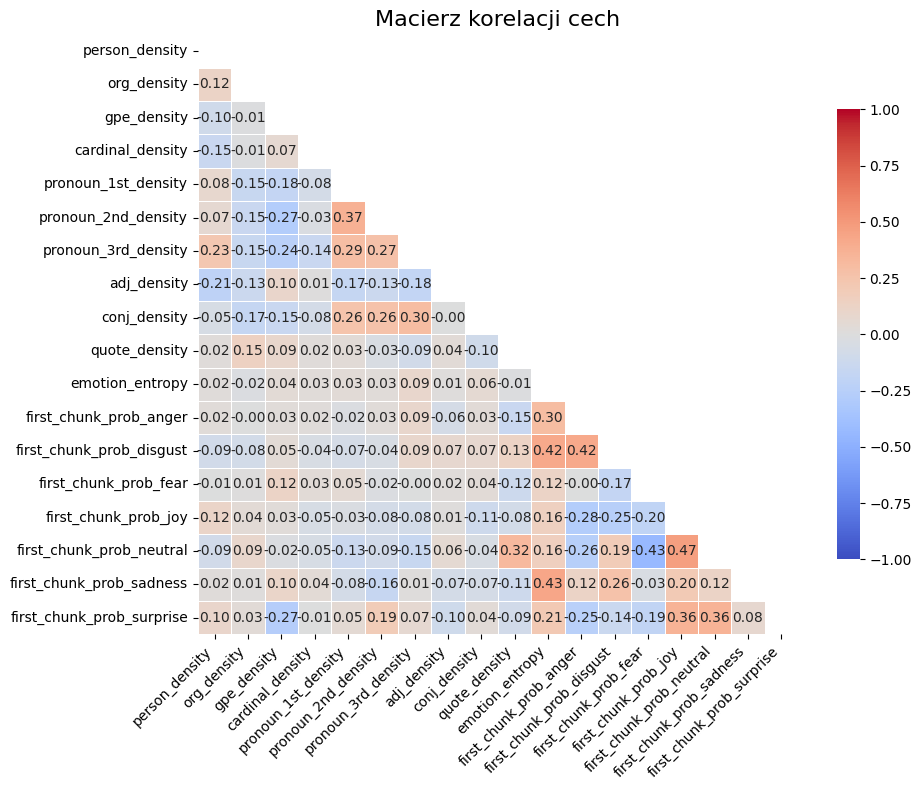

In [308]:
plt.figure(figsize=(10, 8))
plt.title("Macierz korelacji cech", fontsize=16)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5,
            cbar_kws={"shrink": .75})

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Największe współczynniki korelacji wyliczono dla zmiennych dot. analizy z użyciem modelu językowego, mimo tego, nie są to na tyle wysokie wartości, które mogłyby oznaczać współliniowość cech. W celu rozwiązania problemu *dummy variable trap* będziemy musieli usunąć jedną ze zmiennych typu `first_chunk_proba`.

Do dalszej eksploracji cech użyjemy metody *Mutual information*.

In [309]:
mi_scores = mutual_info_classif(X, Y, random_state=42)

C:\Users\gabri\AppData\Local\Temp\ipykernel_12792\3273917216.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


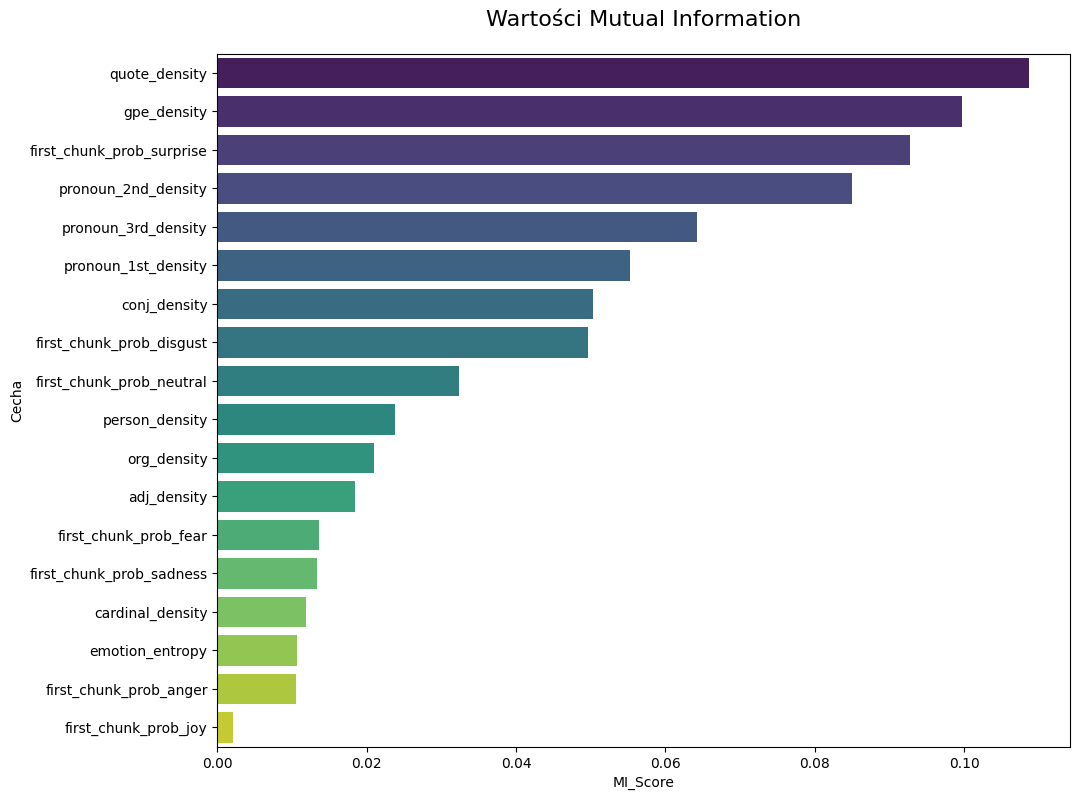

In [ ]:
mi_results = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

plt.figure(figsize=(11, 9)) 
plt.title("Wartości Mutual Information", fontsize=16, pad=20)

sns.barplot(
    x='MI_Score', 
    y='Feature', 
    data=mi_results, 
    palette="viridis"
)
plt.show()

Powyższy wykres potwierdza naszą hipotezę, że cechy emocji słabo różnicują reprezentantów obu populacji. Mimo najniższych wartości dla tych zmiennych na tym etapie, decydujemy się jeszcze zostawić je w zbiorze, pozbywamy się jedynie zmiennej `first_chunk_prob_joy`.

In [311]:
X = X.drop(columns=['first_chunk_prob_joy'])

In [312]:
X.shape

(9212, 17)

Dokonujemy podziału na próby uczącą, walidacyjną oraz testową. Dzielimy tak, aby zachować równe proporcje obserwacji względem klasy artykułu oraz źródła, po to, abyśmy mieli pewność, że model będzie miał ekspozycje również na nowe artykuły, które stanowią mniejszość w naszym datasecie.

In [313]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y,
    test_size=0.20,
    random_state=42,
    stratify=data[['label', 'source_category']]
)

In [314]:
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [315]:
scaler = StandardScaler()

In [240]:
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

Użujemy jednej z metod dobou optymalnego zbioru cech. Dobór opieramy na podstawie modelu xgboost oraz metryce `F1-score`, która będzie główną metryką w problemie.

In [ ]:
estimator = xgb.XGBClassifier(random_state=42, n_jobs=-1)

rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    min_features_to_select=1, 
    n_jobs=-1
)

In [319]:
rfecv.fit(X_train_scaled, y_train)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,"XGBClassifier...ree=None, ...)"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'f1'
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only available when `estimator` is a classifier.","ndarray[int64](2,)","[0,1]"
"cv_results_ cv_results_: dict of ndarraysAll arrays (values of the dictionary) are sorted in ascending orderby the number of features used (i.e., the first element of the arrayrepresents the models that used the least number of features, while thelast element represents the models that used all available features)... versionadded:: 1.0This dictionary contains the following keys:split(k)_test_score : ndarray of shape (n_subsets_of_features,) The cross-validation scores across (k)th fold.mean_test_score : ndarray of shape (n_subsets_of_features,) Mean of scores over the folds.std_test_score : ndarray of shape (n_subsets_of_featur

In [320]:
[col for col, keep in zip(X.columns, rfecv.support_) if not keep]

[]

Algorytm doboru cech *RFECV* zachował wszystkie cechy.

Rozpoczynamy od stworzenia baseline'owych modeli.

In [321]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier( random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42, probability=True),
    "MLP": MLPClassifier(random_state = 42)
}

In [322]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [323]:
results = []

for name, model in models.items():
    cv_results = cross_validate(
        model, X_train_scaled, y_train,
        cv=CV,
        scoring={'accuracy': 'accuracy', 'f1': 'f1',
                 'recall': 'recall', 'precision': 'precision'},
        n_jobs=-1,
    )
 
    # Predykcja na valid secie
    model.fit(X_train_scaled, y_train)
    y_valid_pred = model.predict(X_valid_scaled)
 
    results.append({
        'Model':          name,
        # CV na train
        'CV Accuracy':    round(cv_results['test_accuracy'].mean(), 3),
        'CV F1':          round(cv_results['test_f1'].mean(), 3),
        'CV Recall':      round(cv_results['test_recall'].mean(), 3),
        'CV Precision':   round(cv_results['test_precision'].mean(), 3),
        # Metryki na valid
        'Valid Accuracy': round(accuracy_score(y_valid, y_valid_pred), 3),
        'Valid F1':       round(f1_score(y_valid, y_valid_pred), 3),
        'Valid Recall':   round(recall_score(y_valid, y_valid_pred), 3),
        'Valid Precision':round(precision_score(y_valid, y_valid_pred), 3),
    })

c:\Users\gabri\Desktop\article-credibility\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gabri\Desktop\article-credibility\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [324]:
results_df = pd.DataFrame(results).sort_values(by="Valid F1", ascending=False).reset_index(drop=True)

Wartości metryk dla modeli baseline'owych wyznaczone w oparciu o metodę *cross-validation* na 5 foldach oraz na zbiorze walidacyjnym:

In [325]:
results_df

,Model,CV Accuracy,CV F1,CV Recall,CV Precision,Valid Accuracy,Valid F1,Valid Recall,Valid Precision
0,XGBoost,0.879,0.880,0.862,0.898,0.877,0.877,0.846,0.909
1,Random Forest,0.877,0.876,0.847,0.908,0.869,0.868,0.840,0.898
2,MLP,0.858,0.859,0.846,0.874,0.838,0.837,0.806,0.870
3,SVM,0.854,0.853,0.826,0.883,0.825,0.822,0.783,0.865


In [326]:
results_df[['Model', 'CV F1', 'Valid F1']]

,Model,CV F1,Valid F1
0,XGBoost,0.880,0.877
1,Random Forest,0.876,0.868
2,MLP,0.859,0.837
3,SVM,0.853,0.822


Aby zmienjszyć zjawisko przeuczenia modeli, użyjemy biblioteki do automtycznego tuningu paramterów `optuna`.

In [63]:
def make_objective(model_name):

    def objective(trial):
        if model_name == "Random Forest":
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 250),
                'max_depth': trial.suggest_int('max_depth', 3, 15),          
                'min_samples_split': trial.suggest_int('min_samples_split', 5, 25),
                # NOWE: Zmusza model do uogólniania
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 20),
                'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
            }
            model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)

        elif model_name == "XGBoost":
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 500),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 15), 
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
            }
            model = xgb.XGBClassifier(**params, random_state=42, eval_metric='logloss', n_jobs=-1)

        elif model_name == "SVM":
            params = {
                'C': trial.suggest_float('C', 0.01, 100.0, log=True),
                'gamma': trial.suggest_categorical('gamma', ['scale', 'auto'])
            }
            model = SVC(**params, probability=True, kernel='rbf', random_state=42)

        elif model_name == "MLP":
            params = {
                'hidden_layer_sizes': trial.suggest_categorical(
                    'hidden_layer_sizes',
                    [
                        (32, ), (64,), (128,),                        
                        (128, 64), (64, 32),
                        (16, 32, 64)
                    ] 
                ),
                'activation': trial.suggest_categorical('activation', ['relu', 'tanh']), 
                'alpha': trial.suggest_float('alpha', 0.0001, 1.0, log=True),
                'learning_rate_init': trial.suggest_float('learning_rate_init', 0.0001, 0.03, log=True)
            }
            model = MLPClassifier(**params, random_state=42)

        else:
            raise ValueError(f"Nieznany model: {model_name}")

        scores = cross_val_score(
            model, X_train_scaled, y_train,
            cv=CV,
            scoring='f1',  
            n_jobs=-1,
        )
        return scores.mean()

    return objective

In [64]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
best_results      = []
best_models_tuned = {}
 
for model_name in results_df['Model']:
    print(f"\nTuning modelu: {model_name}...")
 
    study = optuna.create_study(
        direction='maximize',
        study_name=model_name,
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    study.optimize(make_objective(model_name), n_trials=100)
 
    best_params = study.best_params
    best_cv_f1  = study.best_value
    print(f"  Najlepsze CV F1: {best_cv_f1:.4f}")
    print(f"  Parametry: {best_params}")
 
    if model_name == "Random Forest":
        best_model = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
    elif model_name == "XGBoost":
        best_model = xgb.XGBClassifier(**best_params, random_state=42, n_jobs=-1)
    elif model_name == "SVM":
        best_model = SVC(**best_params, probability=True, random_state=42)
    elif model_name == "MLP":
        best_model = MLPClassifier(**best_params, solver='adam', learning_rate='adaptive', early_stopping=True, random_state=42)
 
    best_model.fit(X_train_scaled, y_train)
    best_models_tuned[model_name] = best_model
 
    y_valid_pred = best_model.predict(X_valid_scaled)
    valid_f1     = f1_score(y_valid, y_valid_pred)
    print(f"  Valid F1: {valid_f1:.4f}")
 
    best_results.append({
        'Model':        model_name,
        'CV F1 (mean)': round(best_cv_f1, 3),
        'Valid F1':     round(valid_f1, 3),
        'Best Params':  best_params,
    })


Tuning modelu: XGBoost...
  Najlepsze CV F1: 0.8851
  Parametry: {'n_estimators': 487, 'max_depth': 9, 'learning_rate': 0.024040615983828003, 'subsample': 0.8125546334418448, 'colsample_bytree': 0.5679911521422569, 'min_child_weight': 2, 'reg_alpha': 0.01423447292651801, 'reg_lambda': 0.14855399751894757}
  Valid F1: 0.8840

Tuning modelu: Random Forest...
  Najlepsze CV F1: 0.8753
  Parametry: {'n_estimators': 240, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
  Valid F1: 0.8650

Tuning modelu: MLP...


c:\Users\gabri\Desktop\article-credibility\.venv\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (32,) which is of type tuple.
  optuna_warn(message)
c:\Users\gabri\Desktop\article-credibility\.venv\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64,) which is of type tuple.
  optuna_warn(message)
c:\Users\gabri\Desktop\article-credibility\.venv\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (128,) which is of type tuple.
  optuna_warn(message)
c:\Users\gabri\Desktop\article-credibility\.venv\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categoric

  Najlepsze CV F1: 0.8638
  Parametry: {'hidden_layer_sizes': (128, 64), 'activation': 'tanh', 'alpha': 0.027434173384607314, 'learning_rate_init': 0.00027290671519622793}
  Valid F1: 0.8372

Tuning modelu: SVM...
  Najlepsze CV F1: 0.8596
  Parametry: {'C': 3.550475938875783, 'gamma': 'scale'}


c:\Users\gabri\Desktop\article-credibility\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Valid F1: 0.8233


In [327]:
optuna_result = pd.DataFrame(best_results).sort_values(by="Valid F1", ascending=False).reset_index(drop=True)

In [328]:
optuna_result

,Model,CV F1 (mean),Valid F1,Best Params
0,XGBoost,0.885,0.884,"{'n_estimators': 487, 'max_depth': 9, 'learning_rate': 0.024040615983828003, 'subsample': 0.8125546334418448, 'colsample_bytree': 0.5679911521422569, 'min_child_weight': 2, 'reg_alpha': 0.01423447292651801, 'reg_lambda': 0.14855399751894757}"
1,Random Forest,0.875,0.865,"{'n_estimators': 240, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}"
2,MLP,0.864,0.837,"{'hidden_layer_sizes': (128, 64), 'activation': 'tanh', 'alpha': 0.027434173384607314, 'learning_rate_init': 0.00027290671519622793}"
3,SVM,0.860,0.823,"{'C': 3.550475938875783, 'gamma': 'scale'}"


Tuning hiperparamterów nie rozwiązał problemu przeucenia modeli, jedynym wyjątkiem jest model xgboost.

Wykorzystamy tuningowane modele do stworzenia klasyfikatora ensemble - wykorzystamy technikę stacking z regresją logistyczną jako meta learner.

In [329]:
estimators = [
    ('rf', best_models_tuned["Random Forest"]),
    ('xgb', best_models_tuned["XGBoost"]),
    ('svm', best_models_tuned["SVM"]),
    ('mlp', best_models_tuned["MLP"])
]

meta_learner_model = LogisticRegression(random_state=42)

In [330]:
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_learner_model, 
    cv=5,              
    n_jobs=-1,          
    passthrough=False
)

In [331]:
stacking_clf.fit(X_train_scaled, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('xgb', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[RandomForestC...ndom_state=42), XGBClassifier...ree=None, ...), SVC(C=3.55047...ndom_state=42), MLPClassifier...ndom_state=42)]"
final_estimator_ final_estimator_: estimatorThe classifier fit on the output of `estimators_` and responsible forfinal predictions.,LogisticRegression,LogisticRegre...ndom_stat

In [332]:
y_valid_pred = stacking_clf.predict(X_valid_scaled)

In [333]:
round(f1_score(y_valid, y_valid_pred), 3)

0.878

Zbudowany model w oparciu o tuningowane modele ma drugi największy wynik *F1-Score* na zbiorze walidacyjnym.

Zbadajmy jakie błędy są popełniane przez dwa najlepsze modele: tuningowany model xgboost oraz meta learnera zbudowanego na tuningowanych modelach.

In [334]:
xgb_optuna_params = optuna_result.loc[optuna_result['Model'] == 'XGBoost', 'Best Params'].values[0]
xgb_optuna = xgb.XGBClassifier(**xgb_optuna_params, random_state=42, eval_metric='logloss', n_jobs=-1)

In [335]:
xgb_optuna.fit(X_train_scaled, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5679911521422569
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


C:\Users\gabri\AppData\Local\Temp\ipykernel_12792\288850719.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


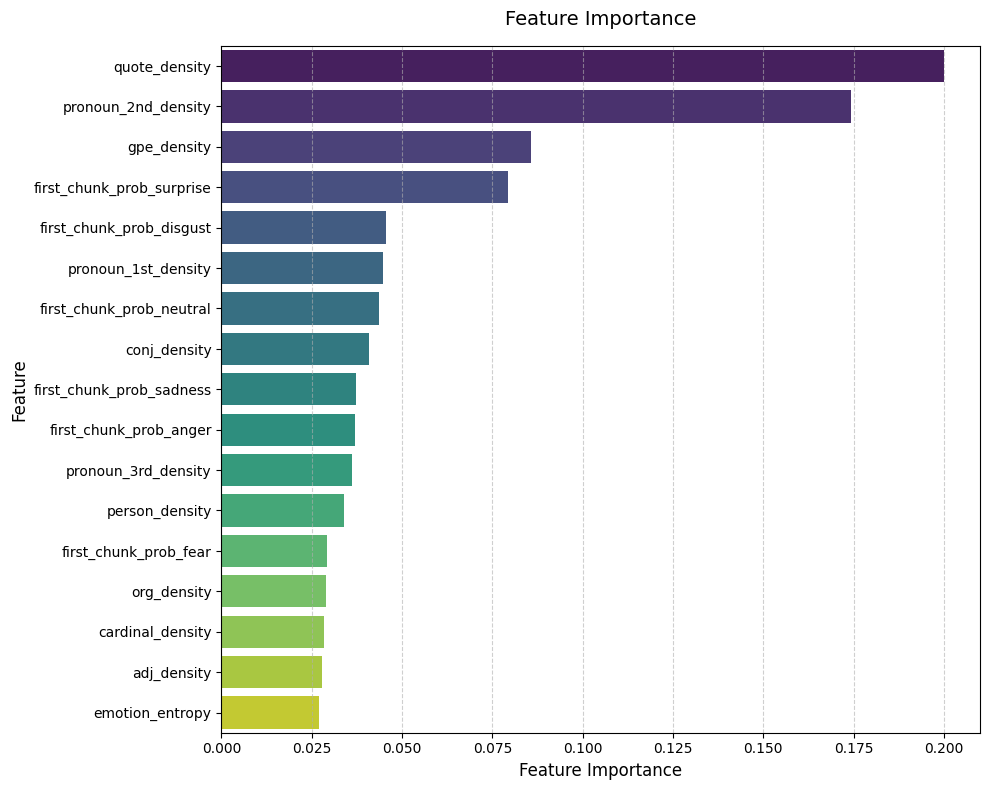

In [336]:
importances = xgb_optuna.feature_importances_

df_importance = pd.DataFrame({
    'Cecha': X.columns,
    'Ważność': importances
}).sort_values(by='Ważność', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=df_importance, 
    x='Ważność', 
    y='Cecha', 
    palette='viridis'
)

plt.title('Feature Importance', fontsize=14, pad=15)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [338]:
xgb_proba = xgb_optuna.predict_proba(X_valid_scaled)[:, 1]
stack_proba = stacking_clf.predict_proba(X_valid_scaled)[:, 1]

In [339]:
xgb_prec, xgb_rec, _ = precision_recall_curve(y_valid, xgb_proba)
stack_prec, stack_rec, _ = precision_recall_curve(y_valid, stack_proba)

xgb_pr_auc = auc(xgb_rec, xgb_prec)
stack_pr_auc = auc(stack_rec, stack_prec)

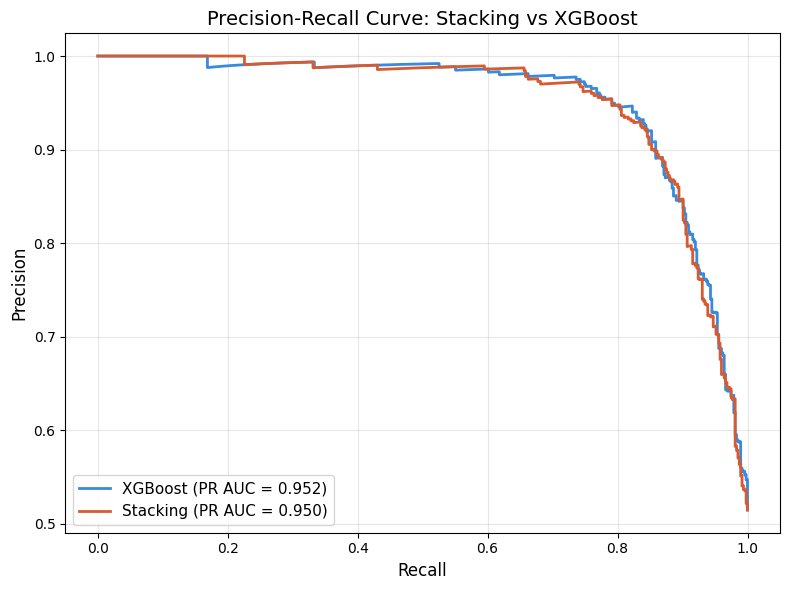

In [340]:
plt.figure(figsize=(8, 6))
plt.plot(xgb_rec, xgb_prec, label=f'XGBoost (PR AUC = {xgb_pr_auc:.3f})', color='#378ADD', lw=2)
plt.plot(stack_rec, stack_prec, label=f'Stacking (PR AUC = {stack_pr_auc:.3f})', color='#D85A30', lw=2)

plt.title('Precision-Recall Curve: Stacking vs XGBoost', fontsize=14)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(loc='lower left', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

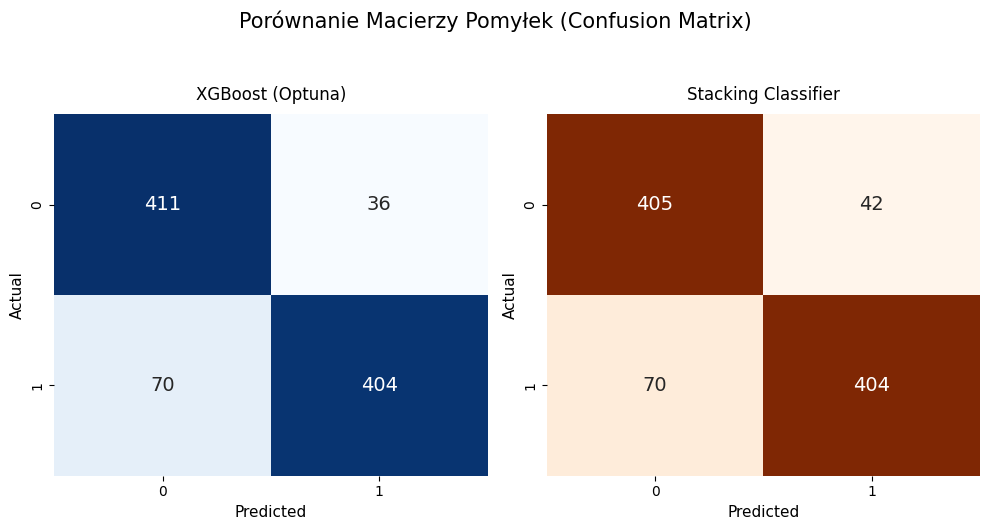

In [353]:
xgb_pred = xgb_optuna.predict(X_valid_scaled)
stack_pred = stacking_clf.predict(X_valid_scaled)

cm_xgb = confusion_matrix(y_valid, xgb_pred)
cm_stack = confusion_matrix(y_valid, stack_pred)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Porównanie Macierzy Pomyłek (Confusion Matrix)', fontsize=15, y=1.05)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0], 
            annot_kws={"size": 14})
axes[0].set_title('XGBoost (Optuna)', fontsize=12, pad=10)
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)

sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1],
            annot_kws={"size": 14})
axes[1].set_title('Stacking Classifier', fontsize=12, pad=10)
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.show()

Model xgboost popełnia mniej błędów niż model stackingu.

Zobaczmy, które artykuły z były najtrudniejsze do poprawnej detekcji dla obu modeli.

In [342]:
both_wrong   = (stack_pred != y_valid) & (xgb_pred != y_valid)

In [343]:
both_wrong_idx = np.where(both_wrong)[0]

original_idx = X_valid.iloc[both_wrong_idx].index

error_df = data.loc[original_idx, ["text", "source_category"]].copy()
error_df["y_true"] = y_valid.iloc[both_wrong_idx]
error_df["stacking_pred"]  = stack_pred[both_wrong_idx]
error_df["stacking_proba"] = stacking_clf.predict_proba(X_valid_scaled[both_wrong_idx])[:, 1]
error_df["xgb_pred"]       = xgb_pred[both_wrong_idx]
error_df["xgb_proba"]      = xgb_optuna.predict_proba(X_valid_scaled[both_wrong_idx])[:, 1]

In [344]:
error_df.shape[0] # liczba tekstów, dla których oba modele się pomyliły

100

In [345]:
error_df.head()

,text,source_category,y_true,stacking_pred,stacking_proba,xgb_pred,xgb_proba
235,"WASHINGTON—President Donald Trump lauded Vice President JD Vance’s leadership of the Task Force to Eliminate Fraud during Wednesday’s White House cabinet meeting. The president brought up the Vance-led task force during his opening remarks at the meeting and likened Vance to Eliot Ness, who, along with The Untouchables, took on Al Capone’s bootlegging syndicate during Prohibition. “Under the leadership of Vice President JD Vance, very proud of this, the White House Task Force to Eliminate Fr...",news_api,1,0,0.249011,0,0.364405
6374,"The late Yogi Berra played in 14 World Series and popped champagne 10 times. We also remember him for all of those things he said, or quotes like this one about the future: “It’s tough to make predictions, especially about the future.” Advertisement Yes, every year we are reminded that it is tough to make predictions, especially about the future. The climate change crusaders are once again being reminded about all of those “forecasts” about melting ice poles and flooded coast lines. Let’s ch...",news_api,1,0,0.101513,0,0.068531
5251,"The most controversial judicial nominee on President Trump s list was just confirmed on Thursday in a U.S. Senate vote catastrophe.Meet John Bush, a lawyer from Kentucky and an outspoken political blogger who bashes on gay rights and who believes that the Roe v. Wade decision was equally as deplorable as the Supreme Court s 1857 pro-slavery decision.This right-wing nutjob is now the newest judge on the 6th Circuit U.S. Court of Appeals.John Bush has published over 400 articles in his career ...",ISOT,1,0,0.234236,0,0.235657
2602,"Pakistanis began casting votes on Sunday for the parliamentary seat vacated by ousted Prime Minister Nawaz Sharif, in a by-election seen as a test of support for the Sharif dynasty ahead of the 2018 general election. Sharif s ruling Pakistan Muslim League-Nawaz (PML-N) party hopes a resounding victory in the eastern city of Lahore would show that support for the family was undiminished despite the Supreme Court s removal of Sharif in July. Sharif s daughter Maryam has spearheaded the PML-N c...",ISOT,0,1,0.839152,1,0.649813
2457,"City taxpayers will dish out $151 million for Gov. Kathy Hochul and state lawmakers’ sweetheart giveaway to public-sector labor unions – largely undoing pension reforms that slightly reined in runaway spending. The Democrats in charge of state government agreed to sweeten the already generous pensions of public employees as part of their painfully slow process to pass a budget, in a move that benefits themselves and the influential unions but will cost taxpayers $6 billion more by 2051. The ...",news_api,1,0,0.145660,0,0.219597


Oba zbiory okazały się być równie problematyczne dla modeli

In [346]:
error_df['source_category'].value_counts()  

source_category
news_api    54
ISOT        46
Name: count, dtype: int64

Najwiekszy problem sprawiły treści zescrapowane za pomocą *NewsAPI* i oznaczone jako nierzetelne. Może to wynikać z założenia, wedle którego były oznaczane te dane - niektóre treści mimo tego, że pochodziły z tabloidów lub stron o średnim wzkaźniku rzetelności (przykładowo *NY Post*) mogły sprawiać wrażenie (a nawet być!) treściami, które wydają się być wiarygodne. 

In [347]:
error_df.groupby(["source_category", "y_true"]).size()

source_category  y_true
ISOT             0         28
                 1         18
news_api         0          6
                 1         48
dtype: int64

Rozkład "pewności" obu modeli jest bardzo zbliżony.

In [300]:
error_df[["stacking_proba", "xgb_proba"]].describe()

,stacking_proba,xgb_proba
count,100.000000,100.000000
mean,0.388489,0.377316
std,0.315150,0.307076
min,0.039825,0.008837
25%,0.108973,0.103152
50%,0.291815,0.302988
75%,0.714836,0.625003
max,0.971861,0.997025


Sprawdźmy jak ostatecznie poradzą sobie oba modele na zbiorze testowym.

In [348]:
test_models = {
    "XGBoost (Optuna)":    xgb_optuna.predict(X_test_scaled),
    "Stacking Classifier": stacking_clf.predict(X_test_scaled),
}

In [349]:
pd.DataFrame([
    {
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, preds), 3),
        "F1":        round(f1_score(y_test, preds), 3),
    }
    for name, preds in test_models.items()
])

,Model,Accuracy,F1
0,XGBoost (Optuna),0.906,0.908
1,Stacking Classifier,0.911,0.914


Finalnie, mimo tego, że na zbiorze walidacyjnym "wygrywał" xgboost, to model ensemble lepiej klasyfikuje artykuły.